In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import RegularGridInterpolator, griddata
from scipy.spatial import ConvexHull
from scipy.spatial.distance import squareform
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
from sklearn.preprocessing import StandardScaler

from utils import *


In [2]:
plt.rcParams.update({
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 7
})
cm_to_inch = 1 / 2.54
width = 4
figsize_cm = (width * cm_to_inch, width * cm_to_inch)  # (9cm, 9cm)
fig_size = figsize_cm

In [ ]:
def reduce_matrix(matrix, seed = 42, labels = None, perplexity = None):    
    # Reduce the matrix to 2 dimensions with MDS
    mds = MDS(n_components=2, random_state=seed, dissimilarity='precomputed')
    coords = mds.fit_transform(matrix)   # Shape is (29, 2)
    return coords
    
def preprocess(csv_file, perplexity = 30, with35 = True):
    source_df = pd.read_csv(csv_file)    
    
    if not with35:df = source_df[~source_df['Name'].str.contains('PDN35', na=False)]
    else:df = source_df
        
    labels = df["Name"]
    fasta_list = list(df['Sequence'])
   
    matrix = 1 - get_identity_matrix(fasta_list) # because sequence distance
    coords = reduce_matrix(matrix, seed = 742, labels = labels,perplexity = perplexity)
    return coords, source_df

def minmax_scale(data, feature_range=(0, 1)):
    # Scale data to the target range; defaults to [0, 1].
    data = np.asarray(data)
    if data.ndim == 1:
        data = data.reshape(-1, 1)
        single_feature = True
    else:
        single_feature = False

    min_vals = data.min(axis=0)
    max_vals = data.max(axis=0)
    range_vals = max_vals - min_vals

    # Avoid division by zero when all values are identical
    range_vals[range_vals == 0] = 1.0

    target_min, target_max = feature_range
    data_scaled = (data - min_vals) / range_vals  # First scale to [0, 1]
    data_scaled = data_scaled * (target_max - target_min) + target_min

    params = {
        'min': min_vals,
        'max': max_vals,
        'range': range_vals,
        'target_min': target_min,
        'target_max': target_max
    }
    if single_feature:data_scaled = data_scaled.flatten()
    return data_scaled, params


def zscore_scale(data):
    # Standardize data to zero mean and unit variance.
    data = np.asarray(data)
    if data.ndim == 1:
        data = data.reshape(-1, 1)
        single_feature = True
    else:
        single_feature = False

    mean_vals = data.mean(axis=0)
    std_vals = data.std(axis=0)
    std_vals[std_vals == 0] = 1.0  # Avoid division by zero

    data_scaled = (data - mean_vals) / std_vals

    params = {
        'mean': mean_vals,
        'std': std_vals
    }
    if single_feature:
        data_scaled = data_scaled.flatten()
    return data_scaled, params

    
def interpolate_energy(x, y, energy, method = 'cubic', region = 100):
    # for our designs is little for better plot
    xi = np.linspace(x.min() , x.max(), region)
    yi = np.linspace(y.min() , y.max(), region)
    XI, YI = np.meshgrid(xi, yi)
    
    # Interpolate energy values on the grid; method can be 'linear' or 'cubic'
    ZI = griddata((x, y), energy, (XI, YI), method=method )
    return XI, YI, ZI, xi, yi

def plot_2d_landscape_arrow(coords, scaled_energy,
                      title = '2D Surface: Energy as f(x, y)',
                      save_file = '2D balabala',
                      cmap = None,
                      lable = None,
                      E = None,
                      delta = 2,
                      start = 19,
                      method = 'cubic',
                      index = 10
                     ):
    # interpolate &  meshgrid

    XI, YI, ZI, x, y = interpolate_energy(coords[:,0], coords[:,1], scaled_energy,     method = method, region = 100)
    # plot mesh
    fig = plt.figure(figsize=fig_size)
    contour = plt.contourf(XI, YI, ZI, levels=15, cmap= cmap, alpha = 0.5)
    cbar = plt.colorbar(contour)
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

    if lable is not None:
        scater_df = pd.DataFrame({'x':coords[:,0], 'y':coords[:,1],'Label':lable})
        sns.scatterplot(data = scater_df, x = 'x', y = 'y', )
    plt.gca().set_axis_off()   

    # plot the gradient direction
    dx = 0.05
    dy = 0.05
    dE_dy, dE_dx = np.gradient(ZI, dy, dx)
    # interpolate grad
    x0, y0 = coords[index]
    interp_dx = RegularGridInterpolator((y,x), dE_dx)
    interp_dy = RegularGridInterpolator((y,x), dE_dy)
    grad_x0 = interp_dx((y0,x0))   # Pass coordinates in (y, x) order
    grad_y0 = interp_dy((y0,x0))
    
    # target grad
    if E == 'U':descent_vec = np.array([grad_x0, grad_y0])
    elif E == 'D':descent_vec = np.array([-grad_x0, -grad_y0])
    else:return None
        
    # specify the grad arraw
    length = 0.15
    if np.linalg.norm(descent_vec) > 0:
        descent_vec = descent_vec / np.linalg.norm(descent_vec) * length
    # plot the only arrow
    plt.quiver(x0, y0, descent_vec[0], descent_vec[1],
              angles='xy', scale_units='xy', scale=1,
              color='red', width=0.02,)
    plt.title(title)
    plt.savefig(save_file)
    plt.show()

d:\miniconda3\envs\plot\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


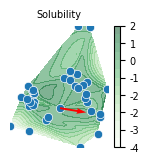

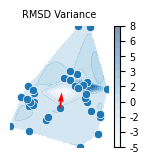

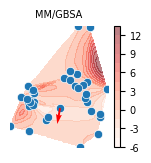

In [4]:
with35 = True # for the PDN35 is a outlier
if not with35:csv_file = '../data/coords.csv'
else:csv_file = '../data/coords_all.csv'
coord_df = pd.read_csv(csv_file)
labels = coord_df["Round"]

coords, df = preprocess('../data/r0-3.csv', perplexity = 3)

# scale z value for better show the peaks
scale_methods = ['minmax', 'zscore', 'no']
scale_method = scale_methods[1]
if scale_method == scale_methods[0]:
    mmgsba_scale, _ = minmax_scale(coord_df['MMGBSA'])
    rmsd_scale, _ = minmax_scale(coord_df['RMSD_var'])
    solubility_scale, _ = minmax_scale(coord_df['Solubility'])
elif scale_method == scale_methods[1]:
    mmgsba_scale, _ = zscore_scale(coord_df['MMGBSA'])
    rmsd_scale, _ = zscore_scale(coord_df['RMSD_var'])
    solubility_scale, _ = zscore_scale(coord_df['Solubility'])
else:
    mmgsba_scale = coord_df['MMGBSA']
    rmsd_scale = coord_df['RMSD_var']
    solubility_scale = coord_df['Solubility']

start = 9 # for we only show the round 1-3 landscape 

index = 4 # for the 4-th is the better point to show our idea

plot_2d_landscape_arrow(coords[start:,:],solubility_scale,save_file = 'solubility_1arraw.svg',E = 'U',lable = labels, index = index, cmap = "Greens", title = 'Solubility',)
plot_2d_landscape_arrow(coords[start:,:],rmsd_scale,save_file = 'rmsd_1arraw.svg',E = 'D',lable = labels , index = index, cmap = 'Blues',title = 'RMSD Variance',)
plot_2d_landscape_arrow(coords[start:,:],mmgsba_scale,save_file = 'mmgsba_1arraw.svg',E = 'D',lable = labels , index = index, cmap = 'Reds',title = 'MM/GBSA',)